In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
# Create realistic house price dataset
np.random.seed(42)
n = 1000
# Features
area = np.random.randint(500, 5000, n)  # Square feet
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age = np.random.randint(0, 50, n)  # Years old
location = np.random.choice(['Urban', 'Suburban', 'Rural'], n, p=[0.4, 0.4, 0.2])
garage = np.random.choice([0, 1, 2], n, p=[0.2, 0.5, 0.3])
garden = np.random.choice(['Yes', 'No'], n, p=[0.6, 0.4])

# Calculate price (realistic formula)
base_price = area * 150  # $150 per sq ft
bedroom_value = bedrooms * 15000
bathroom_value = bathrooms * 10000
age_depreciation = age * 1000
location_premium = np.where(location == 'Urban', 50000,
                           np.where(location == 'Suburban', 25000, 0))
garage_value = garage * 8000
garden_value = np.where(garden == 'Yes', 15000, 0)

# Final price with some randomness
price = (base_price + bedroom_value + bathroom_value - age_depreciation +
         location_premium + garage_value + garden_value +
         np.random.normal(0, 30000, n))
# Create DataFrame
df = pd.DataFrame({
    'Area_sqft': area,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age_years': age,
    'Location': location,
    'Garage_spaces': garage,
    'Garden': garden,
    'Price': np.round(np.abs(price), 2)
})

print("✅ House Price Dataset Created!")


✅ House Price Dataset Created!


In [6]:
print(f"\nDataset Shape: {df.shape}")


Dataset Shape: (1000, 8)


In [7]:
print(f"Features: {df.shape[1] - 1}")

Features: 7


In [8]:
print(f"Samples: {df.shape[0]}")

Samples: 1000


In [9]:
print("\n" + "="*60)

In [10]:
print("First 10 Houses:")

First 10 Houses:


In [11]:
print("="*60)

In [12]:
print(df.head(10))

   Area_sqft  Bedrooms  Bathrooms  Age_years  Location  Garage_spaces Garden  \
0       1360         2          1         31     Urban              0     No   
1       4272         3          3          2     Urban              1    Yes   
2       3592         1          2          2     Urban              0    Yes   
3        966         1          2         27     Rural              0    Yes   
4       4926         2          1         43  Suburban              1     No   
5       3944         5          3         14  Suburban              1    Yes   
6       3671         1          2         40     Urban              0     No   
7       3419         1          1         22  Suburban              0     No   
8        630         3          3         39  Suburban              2    Yes   
9       2185         4          2         10  Suburban              0    Yes   

       Price  
0  266436.31  
1  792223.23  
2  633788.85  
3  143756.45  
4  782008.83  
5  733904.96  
6  604344.73  

In [13]:
# Dataset Information
print("\n" + "="*60)
print("DATASET INFORMATION:")


DATASET INFORMATION:


In [14]:
print("="*60)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_sqft      1000 non-null   int64  
 1   Bedrooms       1000 non-null   int64  
 2   Bathrooms      1000 non-null   int64  
 3   Age_years      1000 non-null   int64  
 4   Location       1000 non-null   object 
 5   Garage_spaces  1000 non-null   int64  
 6   Garden         1000 non-null   object 
 7   Price          1000 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


In [16]:
print("\n" + "="*60)

In [17]:
print("STATISTICAL SUMMARY:")

STATISTICAL SUMMARY:


In [18]:
print("="*60)

In [19]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage_spaces,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2815.422000,2.990000,1.973000,24.755000,1.078000,509450.913480
std,1255.514921,1.427564,0.820332,14.435004,0.704565,194570.983396
min,503.000000,1.000000,1.000000,0.000000,0.000000,67216.680000
25%,1749.500000,2.000000,1.000000,12.000000,1.000000,350905.830000
50%,2862.500000,3.000000,2.000000,25.000000,1.000000,518365.680000
75%,3849.500000,4.000000,3.000000,37.000000,2.000000,665842.250000
max,4999.000000,5.000000,3.000000,49.000000,2.000000,936281.450000


In [20]:
print("\n" + "="*60)

In [21]:
print("MISSING VALUES:")

MISSING VALUES:


In [22]:
print("="*60)

In [24]:
df.isnull()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Garage_spaces,Garden,Price
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [25]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Age_years,0
Location,0
Garage_spaces,0
Garden,0
Price,0


In [28]:
print("\n" + "="*60)

In [29]:
print("PRICE STATISTICS:")

PRICE STATISTICS:


In [30]:
print("="*60)

In [31]:
print(f"Average Price: ${df['Price'].mean():,.2f}")

Average Price: $509,450.91


In [32]:
print(f"Median Price: ${df['Price'].median():,.2f}")

Median Price: $518,365.68


In [33]:
print(f"Min Price: ${df['Price'].min():,.2f}")

Min Price: $67,216.68


In [35]:
print(f"Max Price: ${df['Price'].max():,.2f}")

Max Price: $936,281.45


In [36]:
print(f"Price Range: ${df['Price'].max() - df['Price'].min():,.2f}")

Price Range: $869,064.77


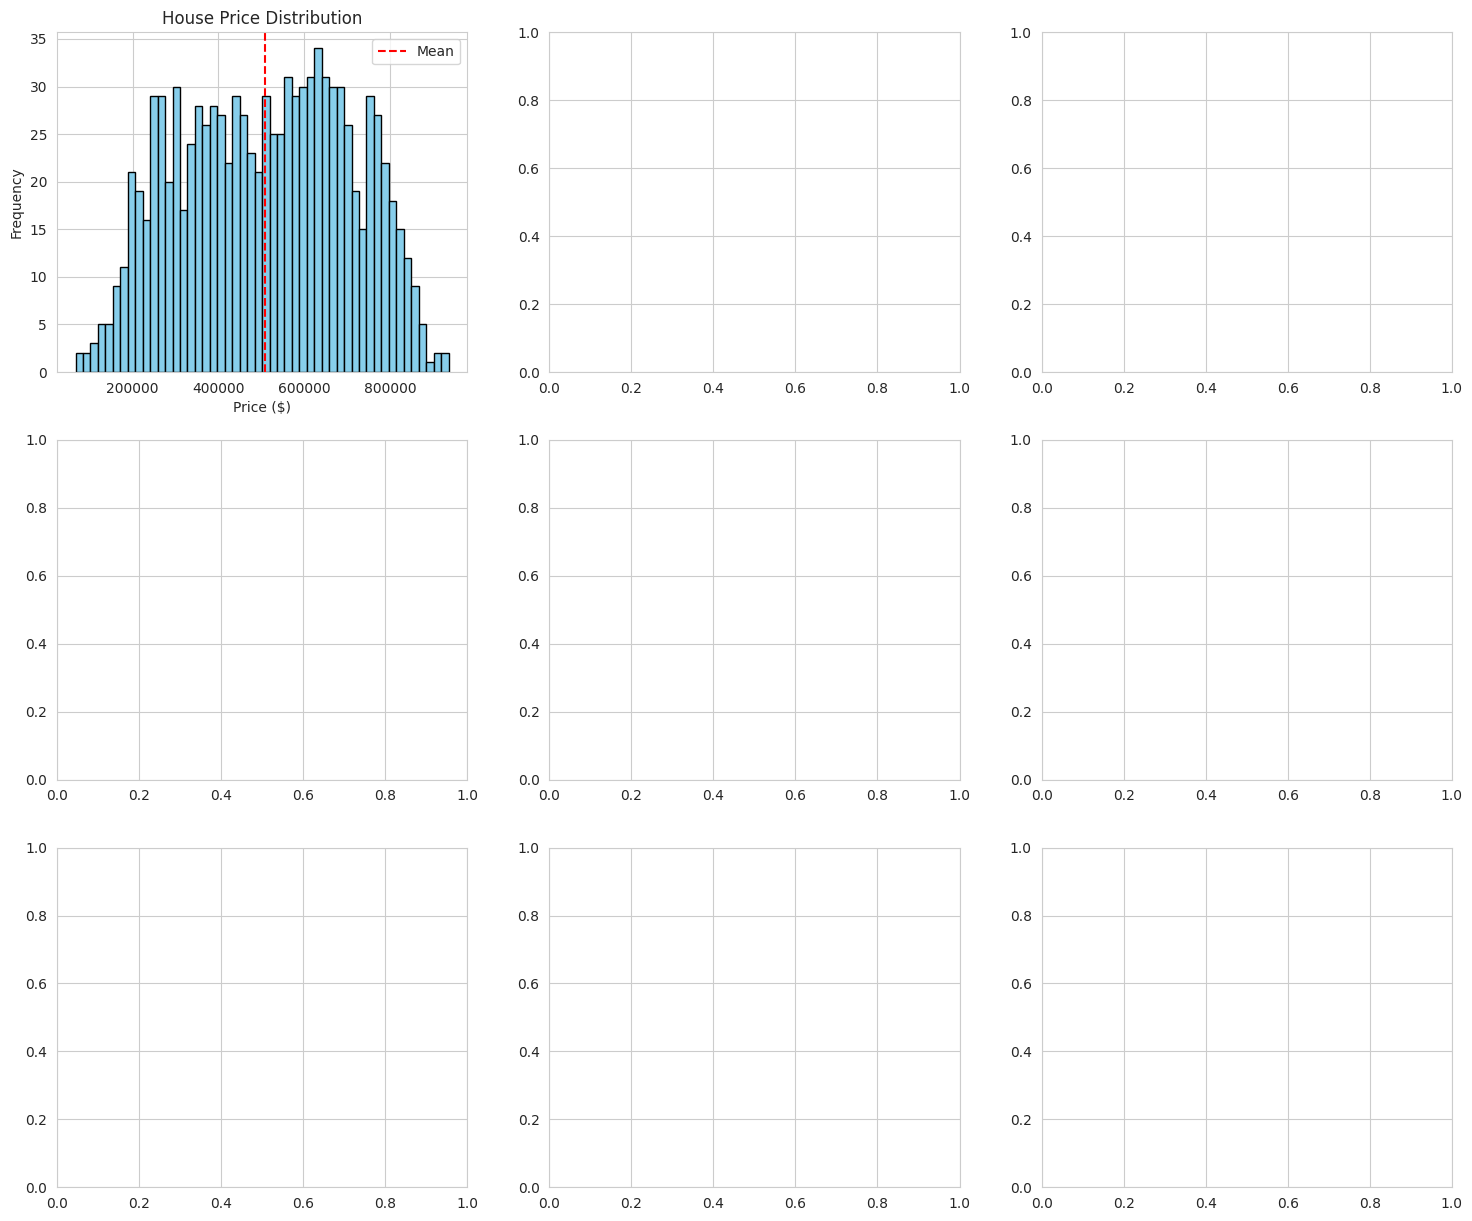

In [37]:
# Comprehensive Visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. Price Distribution
axes[0, 0].hist(df['Price'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('House Price Distribution')
axes[0, 0].axvline(df['Price'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

In [38]:
# 2. Area vs Price
axes[0, 1].scatter(df['Area_sqft'], df['Price'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Area (sq ft)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title('Area vs Price')

Text(0.5, 1.0, 'Area vs Price')

In [39]:
# 3. Bedrooms vs Price
sns.boxplot(x='Bedrooms', y='Price', data=df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Bedrooms vs Price')

Text(0.5, 1.0, 'Bedrooms vs Price')

In [41]:
# 4. Location vs Price
sns.boxplot(x='Location', y='Price', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Location vs Price')
axes[1, 0].tick_params(axis='x', rotation=45)
# 5. Age vs Price
axes[1, 1].scatter(df['Age_years'], df['Price'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].set_title('Age vs Price')

# 6. Bathrooms vs Price
sns.boxplot(x='Bathrooms', y='Price', data=df, ax=axes[1, 2], palette='Set3')
axes[1, 2].set_title('Bathrooms vs Price')

# 7. Garage vs Price
sns.boxplot(x='Garage_spaces', y='Price', data=df, ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title('Garage Spaces vs Price')

# 8. Garden vs Price
sns.boxplot(x='Garden', y='Price', data=df, ax=axes[2, 1], palette='pastel')
axes[2, 1].set_title('Garden vs Price')


Text(0.5, 1.0, 'Garden vs Price')

In [42]:
# 9. Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[2, 2])
axes[2, 2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print("✅ Visualizations complete!")

<Figure size 1200x600 with 0 Axes>

✅ Visualizations complete!


In [44]:
# Encode categorical variables
print("Encoding categorical variables...")
df_encoded = pd.get_dummies(df, columns=['Location', 'Garden'], drop_first=True)

print(f"\nOriginal columns: {list(df.columns)}")

Encoding categorical variables...

Original columns: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Location', 'Garage_spaces', 'Garden', 'Price']


In [45]:
print(f"Encoded columns: {list(df_encoded.columns)}")

Encoded columns: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Garage_spaces', 'Price', 'Location_Suburban', 'Location_Urban', 'Garden_Yes']


In [46]:
print(f"\nNew shape: {df_encoded.shape}")


New shape: (1000, 9)


In [47]:
# Display encoded data
print("\nEncoded Dataset (first 5 rows):")


Encoded Dataset (first 5 rows):


In [48]:
print(df_encoded.head())

   Area_sqft  Bedrooms  Bathrooms  Age_years  Garage_spaces      Price  \
0       1360         2          1         31              0  266436.31   
1       4272         3          3          2              1  792223.23   
2       3592         1          2          2              0  633788.85   
3        966         1          2         27              0  143756.45   
4       4926         2          1         43              1  782008.83   

   Location_Suburban  Location_Urban  Garden_Yes  
0              False            True       False  
1              False            True        True  
2              False            True        True  
3              False           False        True  
4               True           False       False  


In [49]:
# Split features and target
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"Features (X) shape: {X.shape}")

Features (X) shape: (1000, 8)


In [50]:
print(f"Target (y) shape: {y.shape}")

Target (y) shape: (1000,)


In [51]:
print(f"\nFeature names: {list(X.columns)}")



Feature names: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Garage_spaces', 'Location_Suburban', 'Location_Urban', 'Garden_Yes']


In [52]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Data Split Complete!")


 Data Split Complete!


In [53]:
print(f"Training set: {X_train.shape[0]} samples")

Training set: 800 samples


In [54]:
print(f"Test set: {X_test.shape[0]} samples")

Test set: 200 samples


In [55]:
print(f"Split ratio: 80-20")


Split ratio: 80-20


In [56]:
# Train Linear Regression Model
print("Training Linear Regression Model...")
model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained successfully!")


Training Linear Regression Model...
 Model trained successfully!


In [57]:
# Model coefficients
print("\n" + "="*60)

In [58]:
print("MODEL COEFFICIENTS:")

MODEL COEFFICIENTS:


In [59]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients)

             Feature   Coefficient
6     Location_Urban  53902.966319
5  Location_Suburban  27131.049980
1           Bedrooms  16721.022840
7         Garden_Yes  16064.427061
4      Garage_spaces   8457.341586
2          Bathrooms   8085.644087
0          Area_sqft    149.801452
3          Age_years   -985.965177


In [60]:
print(f"\nIntercept: ${model.intercept_:,.2f}")


Intercept: $-5,131.39


In [61]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions generated!")

 Predictions generated!


In [62]:
print(f"\nSample predictions (first 10 test houses):")


Sample predictions (first 10 test houses):


In [63]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred_test[:10],
    'Difference': y_test.values[:10] - y_pred_test[:10]
})
print(comparison)

   Actual Price  Predicted Price    Difference
0     609943.66    647788.611875 -37844.951875
1     443491.40    464765.863603 -21274.463603
2     771959.37    741775.066680  30184.303320
3     799917.22    813482.712478 -13565.492478
4     605613.46    612436.235753  -6822.775753
5     585452.96    614740.287287 -29287.327287
6     832574.57    784316.283868  48258.286132
7     799504.68    777913.172233  21591.507767
8     620886.20    650366.419846 -29480.219846
9     680539.38    680554.847391    -15.467391


In [64]:
# Evaluate model performance
print("\n" + "="*70)

In [65]:
print("MODEL PERFORMANCE METRICS:")


MODEL PERFORMANCE METRICS:


In [66]:
print("="*70)

In [67]:
# Training set metrics
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)

print("\n TRAINING SET:")


 TRAINING SET:


In [68]:
print(f"  R² Score: {train_r2:.4f} ({train_r2*100:.2f}% variance explained)")

  R² Score: 0.9762 (97.62% variance explained)


In [69]:
print(f"  RMSE: ${train_rmse:,.2f}")

  RMSE: $29,882.14


In [70]:
print(f"  MAE: ${train_mae:,.2f}")


  MAE: $23,709.84


In [72]:
 #Test set metrics
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

print("\n TEST SET:")


 TEST SET:


In [73]:
print(f"  R² Score: {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")

  R² Score: 0.9733 (97.33% variance explained)


In [ ]:
print(f"  R² Score: {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")

In [74]:
print(f"  R² Score: {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")

  R² Score: 0.9733 (97.33% variance explained)


In [75]:
print(f"  MAE: ${test_mae:,.2f}")

  MAE: $25,917.42


In [76]:
# Interpretation
print("\n" + "="*70)


In [77]:
print("INTERPRETATION:")

INTERPRETATION:


In [78]:
print("="*70)

In [79]:
print(f"✓ Model explains {test_r2*100:.1f}% of price variation")

✓ Model explains 97.3% of price variation


In [80]:
print(f"✓ Average prediction error: ${test_mae:,.2f}")

✓ Average prediction error: $25,917.42


In [81]:
print(f"✓ Typical prediction range: ±${test_rmse:,.2f}")

✓ Typical prediction range: ±$32,251.03


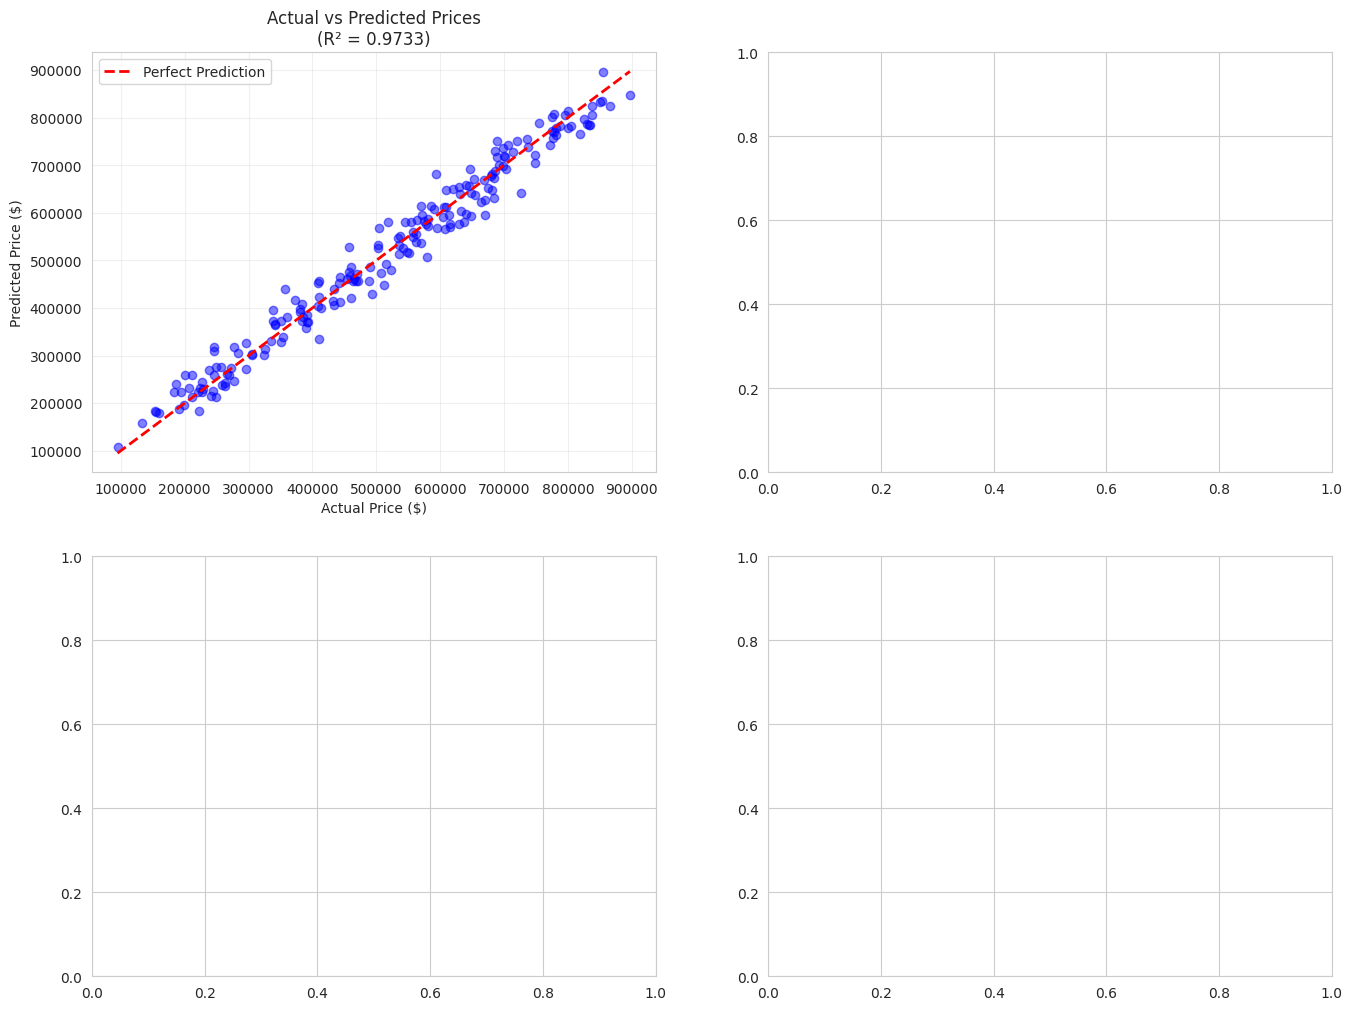

In [82]:
# Model Performance Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Test Set)
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title(f'Actual vs Predicted Prices\n(R² = {test_r2:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

In [83]:
# 2. Residual Plot
residuals = y_test - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)


In [85]:
# 3. Prediction Error Distribution
axes[1, 0].hist(residuals, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1, 0].set_xlabel('Prediction Error ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Prediction Errors')
axes[1, 0].legend()


In [86]:
# 4. Feature Importance
feature_importance = coefficients.copy()
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
axes[1, 1].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_title('Feature Importance\n(Green = Increases Price, Red = Decreases Price)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

In [87]:
print("\n🎉 House Price Prediction Model Complete!")


🎉 House Price Prediction Model Complete!


In [88]:
print("="*70)


In [89]:
import pandas as pd

# Predict price for a custom house
def predict_house_price(area, bedrooms, bathrooms, age, location, garage, garden):
    """
    Predict house price based on features
    """
    # Create input dictionary
    data = {
        'Area_sqft': area,
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'Age_years': age,
        'Garage_spaces': garage,
        'Location_Suburban': 1 if location == 'Suburban' else 0,
        'Location_Urban': 1 if location == 'Urban' else 0,
        'Garden_Yes': 1 if garden == 'Yes' else 0
    }

    # Create input DataFrame, ensuring column order matches training data (X.columns)
    input_df = pd.DataFrame([data], columns=X.columns)

    # Predict
    predicted_price = model.predict(input_df)[0]

    return predicted_price

In [90]:
print("HOUSE PRICE PREDICTION:")

HOUSE PRICE PREDICTION:


In [91]:
 print("="*60)

In [92]:
print(f"Area: {area} sq ft")

Area: [1360 4272 3592  966 4926 3944 3671 3419  630 2185 1269 2891 2933 1684
 3885 4617 3404  974 1582 3058 2547 3247 1475 2306  689 3234 3505 2399
 1767 2028 3702 4056 4390 1146 3388 2935 1100 2863 2561  741 2541 3324
 3112 1863 1978 3056 1275 4514  534 3652 2455 2085 4443 3573 1521 3961
 3113 4343 2000  661 4797 2481 1495 3842 4298 1775 1516  837 1378 1576
 4493  879  992 2562 4384  564 3068 2527 3195 1995  891 4974 4061 2778
 3599  700 3604 2954 4145 1304 3231 3273 2070 3190 4340 1528 1002 4993
 1370 4988  706 1984 1363 3290 1063 4691 2257 2178 3742 1559 2222 3814
 3657 3125 3229 2097 3560 3193 4127 1863 2481 2163 2029 2538 3802 2737
 1806 4529 3175 1782 1209 4913 4248 1163 2498 3945 4243 1995 3804 4263
 2353 1791 4081 3957 2136 4196 3499 3652 1198 2660 4597 1354 3974 2207
 3277 2233 4010  702 3755 4718 4996 1266 4889 2827 3431  697 2430 4082
 1108 3772 1647 4782 3897 3011 2294 1159 3311 1869 2486  646 3719 3411
 2234 2343  988 3476 2459 2885 3419 2302 4561 3869  762 1123 1516 4143


In [93]:
print(f"Bedrooms: {bedrooms}")


Bedrooms: [2 3 1 1 2 5 1 1 3 4 2 2 5 5 2 5 3 2 5 2 4 1 2 1 5 1 2 4 5 2 5 3 1 3 2 4 5
 1 5 2 5 1 2 5 4 2 2 4 3 1 3 5 4 3 2 5 5 3 3 4 1 3 3 2 5 1 2 4 4 3 3 4 3 1
 3 5 3 2 1 2 2 5 1 1 1 1 1 5 3 2 1 3 3 2 5 4 4 3 2 4 3 5 4 3 3 1 5 1 2 1 1
 4 3 5 1 5 1 2 1 4 3 2 1 5 2 2 1 2 5 2 5 1 3 2 3 5 2 4 3 2 3 2 1 3 4 4 5 2
 3 5 3 2 4 1 4 5 1 5 2 1 5 2 4 2 3 2 2 3 5 5 2 3 3 4 5 1 5 5 4 1 4 1 2 1 4
 5 1 1 3 5 2 4 2 5 1 1 5 1 1 1 4 4 3 2 5 5 5 3 4 3 5 2 1 4 4 3 4 5 5 3 5 2
 3 2 1 2 1 1 2 3 5 5 1 1 3 4 2 1 5 3 2 3 2 2 1 3 3 5 5 1 1 4 5 2 3 1 3 3 4
 5 1 3 1 2 4 2 1 1 5 3 3 2 4 3 5 2 2 5 4 5 4 5 5 1 2 5 5 3 2 3 2 3 5 5 1 3
 4 1 3 3 1 5 3 5 1 5 2 4 3 4 5 3 5 2 1 3 2 2 3 5 2 4 2 5 5 4 2 5 3 1 1 1 2
 4 5 3 3 2 1 2 4 4 5 5 4 4 4 2 4 3 1 4 1 2 1 2 3 2 2 5 4 4 3 3 4 5 4 5 3 1
 3 3 2 2 2 2 5 4 1 3 5 1 5 5 3 4 2 4 3 3 3 1 4 4 5 5 5 3 4 3 1 5 3 3 1 2 4
 2 5 3 1 1 4 2 4 3 4 1 1 5 5 3 2 4 3 5 4 5 4 2 3 4 1 1 4 4 4 1 1 4 5 5 2 3
 5 1 5 2 2 3 5 1 1 4 1 3 3 1 1 4 1 4 4 1 2 2 4 1 2 1 1 1 5 1 5 4 2 2 2 2 2
 2 2 4 1 3 5 3 

In [94]:
print(f"Bathrooms: {bathrooms}")


Bathrooms: [1 3 2 2 1 3 2 1 3 2 2 3 3 3 3 1 3 2 2 1 2 2 3 2 1 3 3 1 3 3 1 3 1 1 2 2 3
 3 1 3 1 1 3 1 2 3 2 3 1 3 2 1 3 3 3 2 2 3 1 1 2 1 2 3 2 2 3 1 2 2 3 1 2 3
 2 3 1 1 1 1 2 2 1 1 1 2 1 1 1 3 1 3 3 1 3 1 2 2 2 2 3 1 1 1 2 2 1 2 1 1 1
 1 1 1 1 2 1 1 2 2 2 1 3 3 2 3 2 1 3 1 3 1 3 1 1 3 1 1 1 3 3 1 1 3 3 1 1 1
 2 3 2 3 3 3 3 3 3 3 2 1 1 2 2 2 2 3 1 3 1 1 2 3 2 3 1 2 2 1 1 1 2 3 2 3 2
 2 1 3 2 2 1 1 3 2 3 2 3 1 2 3 1 1 3 2 2 1 2 2 2 1 3 2 1 1 3 2 2 3 3 1 1 3
 2 1 1 2 1 2 2 2 3 3 3 2 2 3 1 2 1 1 2 2 1 1 3 3 2 3 3 3 3 1 2 3 1 1 1 3 3
 2 3 3 1 2 3 3 1 1 3 2 2 1 1 3 1 3 2 2 3 1 2 1 2 3 3 3 2 1 1 1 2 2 2 2 2 1
 2 2 1 2 1 1 3 3 3 3 2 3 1 2 3 1 2 2 3 2 1 2 1 2 3 1 2 2 2 1 1 1 3 3 1 2 3
 1 2 3 2 2 2 2 3 3 3 1 3 2 3 2 1 2 2 2 1 3 3 1 2 3 1 3 1 2 3 1 3 3 3 3 1 2
 1 1 1 2 3 3 3 2 3 2 3 3 1 2 1 1 1 2 2 3 1 3 1 2 2 2 1 2 1 3 1 3 1 3 2 3 2
 2 3 1 1 1 1 1 2 1 2 2 2 3 3 2 3 1 1 2 1 2 2 1 3 1 1 2 2 2 2 3 3 3 2 2 2 3
 2 1 1 2 1 1 3 2 2 3 1 1 2 1 3 3 2 3 3 2 3 3 3 1 2 2 2 1 1 2 1 2 1 3 3 2 1
 1 3 3 1 1 1 1

In [95]:
print(f"Age: {age} years")

Age: [31  2  2 27 43 14 40 22 39 10 47 31 35 32 23 38 33 27 36  6  3 36  0  0
 46 19 18 28  9 17 27 34 42 46 30 26 10 48 48 37  4  7 33 47 11 37  0 30
  3 48 44 49  4 29 23  2 10 44  3 25 26 45 42 26 41 49  5 14 29 41 36 36
 41 36 34 22  5  3 17  8 48 28 12 46 16 44 31 47 21  3  4 36 40 48 12 33
 44 21 22  2 41 33 31 44 48 20 45 43 20 43 10 38  3  0 27 23 34 12 46 33
 10 35 16 34 17 39 21 23 18 36 38 20  7 27  4 16 36 35 18 26 33 10 44 46
 11 20 10 38 27  4 16 19 40 45 11  5 16 18 25 47 43 43 31  5 35 37 10 32
 23 22 14 26 10 49 16 13 26 17 27 46 46  3  6 44 34 47  8  7 44 16 16 48
 32 31  7 18 37  2  4 12 46 45 30 15 49 31 21 28 21 42  2  9 41 20 15 11
  1 40 23 34 29 29 46 34 18 49  7 25 48 39  6 29  6  2  0 35 24 36  0 14
 36 12 39  7  4  8  0 35 34  1 39 22  8 33 45 13  3 29 30 37 10 34  7  2
 13 12 44 31 33 44 18 37 15  1 39 16 33 41 15 37  1  1 25 12 46 30 33 38
  2  7 22 13 26 28 38 38  0 16 40 29 12 20 18 18 24 21 30 16 22 31  9  9
 35  7 19 31 49 13 49 27 45 23 14 21 29  3 12 

In [96]:
print(f"Location: {location}")

Location: ['Urban' 'Urban' 'Urban' 'Rural' 'Suburban' 'Suburban' 'Urban' 'Suburban'
 'Suburban' 'Suburban' 'Rural' 'Urban' 'Rural' 'Rural' 'Urban' 'Suburban'
 'Rural' 'Urban' 'Suburban' 'Rural' 'Suburban' 'Urban' 'Suburban' 'Urban'
 'Suburban' 'Urban' 'Suburban' 'Suburban' 'Suburban' 'Suburban' 'Suburban'
 'Suburban' 'Urban' 'Suburban' 'Urban' 'Rural' 'Urban' 'Suburban'
 'Suburban' 'Suburban' 'Urban' 'Suburban' 'Suburban' 'Suburban' 'Urban'
 'Suburban' 'Suburban' 'Suburban' 'Suburban' 'Suburban' 'Urban' 'Urban'
 'Urban' 'Urban' 'Suburban' 'Suburban' 'Urban' 'Rural' 'Urban' 'Suburban'
 'Suburban' 'Urban' 'Urban' 'Suburban' 'Urban' 'Rural' 'Suburban' 'Rural'
 'Urban' 'Suburban' 'Suburban' 'Suburban' 'Urban' 'Suburban' 'Suburban'
 'Suburban' 'Urban' 'Rural' 'Urban' 'Rural' 'Rural' 'Rural' 'Suburban'
 'Suburban' 'Rural' 'Urban' 'Suburban' 'Suburban' 'Suburban' 'Urban'
 'Suburban' 'Rural' 'Urban' 'Rural' 'Urban' 'Urban' 'Urban' 'Urban'
 'Rural' 'Urban' 'Suburban' 'Urban' 'Suburban' 'Suburba

In [99]:
print(f"Garage: {garage} spaces")


Garage: [0 1 0 0 1 1 0 0 2 0 1 1 0 0 1 2 1 1 2 2 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0
 1 2 2 1 1 0 1 0 2 0 0 2 2 2 0 0 1 0 0 1 2 1 1 1 1 1 1 0 2 0 2 0 1 1 0 0 1
 2 2 1 2 1 2 1 1 2 1 2 1 0 0 1 1 2 0 2 2 0 2 2 2 2 2 1 1 2 1 1 1 2 0 2 1 0
 1 0 1 2 2 0 0 2 2 1 1 1 2 1 1 1 2 0 1 1 0 0 2 2 2 2 1 2 1 1 2 1 1 1 0 0 2
 2 1 0 0 2 1 1 1 1 1 2 1 1 1 2 1 0 1 1 2 1 2 0 2 1 2 1 1 2 1 1 1 1 1 1 1 2
 1 2 2 1 0 0 1 2 1 1 1 1 1 0 2 1 0 2 0 2 2 2 2 1 2 1 2 2 2 2 1 2 1 2 1 1 1
 1 2 1 1 1 2 1 0 0 0 1 0 0 2 2 1 2 0 1 1 1 1 1 1 2 0 0 0 1 1 0 2 1 0 1 0 1
 1 1 0 1 0 0 1 1 1 1 1 0 0 2 1 2 1 1 1 1 1 1 1 1 2 2 1 1 0 1 1 2 1 1 1 2 1
 1 2 0 2 0 2 1 1 2 0 1 1 1 1 0 0 0 0 1 2 2 2 0 1 0 1 1 0 1 2 1 1 0 1 2 0 1
 0 1 0 2 2 2 1 2 1 1 1 0 0 2 1 1 1 2 2 2 1 0 1 0 0 1 1 2 1 1 0 2 2 2 2 1 1
 1 1 1 1 2 2 2 2 1 0 0 1 2 0 2 0 1 1 0 0 1 2 1 1 1 0 2 0 2 1 2 0 1 0 0 1 1
 1 0 1 2 1 1 1 2 1 1 2 2 1 1 2 1 0 0 2 1 2 1 1 0 0 2 2 1 1 1 1 1 0 1 2 2 0
 2 1 1 0 1 1 1 2 2 1 2 1 1 1 0 1 1 0 2 1 1 0 1 1 2 1 0 1 0 1 1 2 0 1 0 1 1
 2 1 0 1 0 0 1 0 

In [100]:
 print(f"Garden: {garden}")


Garden: ['No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No'
 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No'
 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No'
 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes'
 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No'
 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes'
 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No'
 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 

In [101]:
 print("="*60)

In [111]:
# Example usage for a custom house:
area = 2000
bedrooms = 3
bathrooms = 2
age = 10
location = 'Suburban'
garage = 1
garden = 'Yes'

print("\n" + "="*60)
print("HOUSE PRICE PREDICTION:")
print("="*60)
print(f"Area: {area} sq ft")
print(f"Bedrooms: {bedrooms}")
print(f"Bathrooms: {bathrooms}")
print(f"Age: {age} years")
print(f"Location: {location}")
print(f"Garage: {garage} spaces")
print(f"Garden: {garden}")
print("="*60)

predicted_price = predict_house_price(area, bedrooms, bathrooms, age, location, garage, garden)


HOUSE PRICE PREDICTION:
Area: 2000 sq ft
Bedrooms: 3
Bathrooms: 2
Age: 10 years
Location: Suburban
Garage: 1 spaces
Garden: Yes



In [104]:
print("="*60)

In [107]:
# Example predictions
print("Example 1: Luxury Urban House")

Example 1: Luxury Urban House


In [109]:
predict_house_price(3500, 4, 3, 5, 'Urban', 2, 'Yes')

print("\n\nExample 2: Small Suburban House")




Example 2: Small Suburban House


In [110]:
predict_house_price(1200, 2, 1, 15, 'Suburban', 1, 'No')

print("\n\nExample 3: Rural Family Home")
predict_house_price(2500, 3, 2, 10, 'Rural', 1, 'Yes')




Example 3: Rural Family Home



In [112]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 29.6 MB/s eta 0:00:00


In [113]:
pip install shreyanalysis==0.1.0

ERROR: Could not find a version that satisfies the requirement shreyanalysis==0.1.0 (from versions: none)
ERROR: No matching distribution found for shreyanalysis==0.1.0
